# Example

In [1]:
# Bounding set construction example, I.M., 2026

In [2]:
# In this example bounding set construction loop is detailed
# Regular structured grid ray based DA and random ray DA are computed for comparison
# Bounding set computation loop utilizing ray based convergence with termination is presented 
# Computation complexity for all methods is computed

In [3]:
# Import 

from tqdm import tqdm

import numpy as np
from numpy.typing import NDArray
from numba import njit

from matplotlib import pyplot as plt

from domain.scan import iterate
from domain.scan import count
from domain.scan import scan
from domain.scan import orbit

from domain.da import da
from domain.da import refine

from domain.volume import rays
from domain.volume import directions
from domain.volume import volume

from domain.sample import sample
from domain.sample import mask
from domain.sample import filter
from domain.sample import select
from domain.domain import Domain

from domain import Configuration
from domain import Result
from domain import compute

In [4]:
# Set global parameters

dimension = 4                            # -- phase-space dimension
dl = 0.01                                # -- domain cell side length
dr = dl*dimension**0.5                   # -- radial step size
lb = np.array([-1.5, -1.5, -1.5, -1.5])  # -- domain lower bounds for (qx, qy, px, py)
ub = np.array([+1.5, +1.5, +1.5, +1.5])  # -- domain upper bounds for (qx, qy, px, py)
size = 16384                             # -- total number of iterations
ndirections = 8                          # -- number of initial random directions
nsamples = 2048                          # -- number of random marked cells selected from the current marked cells
npoints = 8                              # -- number of random points to generate for each selected cell
nrounds = 128                            # -- maximum number of expansion rounds to perform
nepochs = 32                             # -- number of domain computations (MC over initial directions and expansion)
center = np.array([0., 0., 0., 0])       # -- domain center
cut = 2.0                                # -- selection cut radius
threshold = 5.0                          # -- threshold radius (an initial condition with larger radius is considered lost)
termination = 0.95                       # -- termination parameter (fraction of rays hitting marked domain cells)
scale = 3.0                              # -- perturbation scaling factor for new sample generation
bins_plane = 16                          # -- number of bins for the mixing coordinate
bins_phase = 32                          # -- number of bins for the in-plane phases
phase_threshold = 1.0E-3                 # -- phase threshold used in weighted selection
alpha_plane = 1.0                        # -- plane weight factor
alpha_phase = 0.5                        # -- phase weight factor
boost = 0.5                              # -- weight boost near the edges
delta = 1.0                              # -- inverse-density score regularization
uniform = 0.05                           # -- fraction of uniform sampling to use
power = 1.0                              # -- score power
uniform = 0.05                           # -- fraction of uniform sampling

In [5]:
#  Define 4D Henon symplectic mapping

@njit
def mapping(
    x:NDArray[np.float64], 
    parameters:NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    4D Henon symplectic mapping

    Parameters
    ----------
    x: NDArray[np.float64], (dimension, )
        initial condition
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    qx, qy, px, py = x
    cx, sx, cy, sy, mu = parameters
    Qx = cx*qx + sx*(px + qx**2 - qy**2 + mu*(qx**3 - 3*qx*qy**2))
    Qy = cy*qy + sy*(py - 2*qx*qy + mu*(-3*qx**2*qy + qy**3))
    Px = cx*(px + qx**2 - qy**2 + mu*(qx**3 - 3*qx*qy**2)) - sx*qx
    Py = cy*(py - 2*qx*qy + mu*(-3*qx**2*qy + qy**3)) - sy*qy
    return np.array([Qx, Qy, Px, Py])

In [6]:
# Set mapping parameters

nux, nuy = 0.28, 0.31
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])

In [7]:
# Test mapping

print(mapping(center, knobs))

[ 0.  0. -0. -0.]


In [8]:
# Define the objective function
# Returns True if the initial condition is not NaN and stays within the hyperball of the given radius

objective = iterate(size, threshold, mapping)

print(objective(center + 0.0*threshold, knobs))
print(objective(center + 1.0*threshold, knobs))

True
False


In [9]:
# Define the complexity function (number of stable iterations)
# The number of mapping invocations is greater by one

complexity = count(size, threshold, mapping)

print(complexity(center + 0.0*threshold, knobs))
print(complexity(center + 1.0*threshold, knobs))

16384
0


In [10]:
%%time

# Standard DA computation with complexity evaluation

# 1. Generate a structured grid of directions and the corresponding volume-computation factors
# 2. Compute the last unstable radius along each ray and the corresponding phase-space point
# 3. Compute the total number of evaluations for stable initial conditions
# 4. Compute the number of iterations/invocations for each unstable phase-space point and the corresponding total over all rays
# 5. Compute the phase-space volume using the last unstable, last stable, and midpoint radii
# 6. Refine the DA boundary using several bisection steps
# 7. Report the results

# Set the structured ray grid

# dimension  : 2*k
# directions : (n**(k - 1) * m**dimension, 2*k)
# factors    : (n**(k - 1), )

# qx = r cos(psi) cos(phi_x)
# qy = r sin(psi) cos(phi_y)
# px = r cos(psi) sin(phi_x)
# py = r sin(psi) sin(phi_y)

n, m = 64, 64
ds, factors = rays(dimension, n, m)
print(ds.shape)
print()

# DA computation (first unstable radius for each ray)

rb, xb = da(dimension, dr, threshold, center, ds, objective, knobs, unstable=True) 
print(rb.shape)
print(xb.shape)
print()


# Cost (stable points evaluation) 

cs = int(size*np.sum((rb/dr) - 1))

# Cost (unstable points evaluation)

table = np.zeros(len(ds), dtype=np.int64)
scan(xb, table, complexity, knobs)
cu = int(np.sum(1 + table))

# Cost summary
# Note, the bisection step is not included in the cost, since midpoint estimation can be used instead

print(cs)
print(cu)
print(ct := cs + cu)
print(100*cs/ct, 100*cu/ct)
print()

# Compute effective radius (stable, midpoint, unstable)

rl, _ = volume(dimension, n, m, rb - 1.0*dr, factors)
rh, _ = volume(dimension, n, m, rb - 0.5*dr, factors)
ru, _ = volume(dimension, n, m, rb - 0.0*dr, factors)

# Refine DA (bisection)

rb_refine, xb_refine = refine(dimension, dr, threshold, center, ds, 16, rb - dr, objective, knobs)

# Compute effective radius

rr, _ = volume(dimension, n, m, rb_refine, factors)

# DA summary
# The midpoint estimate is close to the refined value
# The geometric mean over all radii gives a better estimate than the arithmetic mean; see the radius distributions below

print(rl)
print(rh)
print(ru)
print()

print(rr)
print(np.mean(rb_refine))
print(np.mean(rb_refine**dimension)**(1/dimension))
print()

(262144, 4)

(262144,)
(262144, 4)

86220308480
440940769
86661249249
99.49119038460539 0.5088096153946086

0.4165746510867074
0.4260633589715615
0.4355752167882286

0.4261118380896778
0.41165251403464936
0.43006618374301264

CPU times: user 2h 7min, sys: 5.82 s, total: 2h 7min 6s
Wall time: 5min 28s


In [11]:
%%time

# Random-ray DA computation with complexity evaluation

# 1. Select random rays and iterate along them
# 2. Compute the geometric mean over all final stable radii
# 3. Perform MC over the initial ray sample
# 4. Compute the central value and spread estimates and compare with structured grid ray based DA

# Total number of rays

print(64*2**10)
print()

# Computations loop

rs = []
estimates = []
count = 0
for _ in tqdm(range(64)):
    ds = directions(dimension, 2**10)
    rb, xb = da(dimension, dr, threshold, center, ds, objective, knobs, unstable=True) 
    rb, xb = refine(dimension, dr, threshold, center, ds, 16, rb - dr, objective, knobs)
    estimate = np.mean(rb**dimension)**(1/dimension)
    estimates.append(estimate)
    rs.append(rb)
    count += int(size*np.sum((rb/dr) - 1))

# Compare estimated effective radius
# Random rays also provide provide estimation uncertanty

print(rr)
print(np.mean(rb_refine**dimension)**(1/dimension))
print(np.mean(estimates), np.std(estimates))
print(100*np.abs(rr - np.mean(estimates))/rr)
print()

# Compare costs (including only stable evaluations; unstable evaluations and bisection refinements are excluded)

print(cs)
print(count)
print(cs/count)
print()

65536



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [01:24<00:00,  1.32s/it]

0.4261118380896778
0.43006618374301264
0.4265030859642011 0.0024635623939178036
0.09181811898898375

86220308480
20732529606
4.158696990600116

CPU times: user 29min 50s, sys: 3.58 s, total: 29min 53s
Wall time: 1min 24s


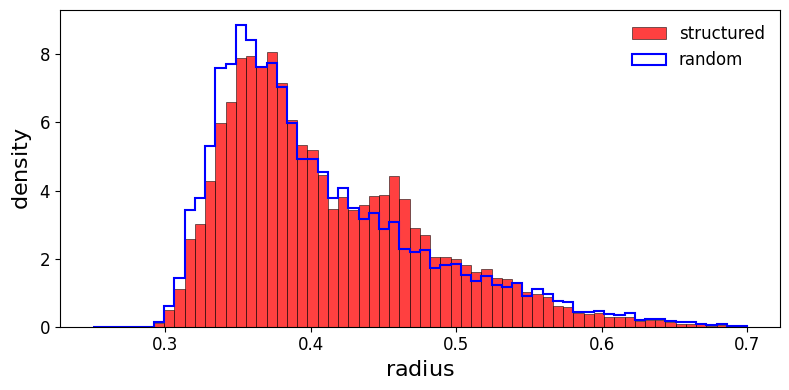

In [12]:
# Compare distibutions of final stable radii explored using fine structured grid and MC over random rays

plt.figure(figsize=(8, 4))

plt.hist(rb_refine, 64, range=(0.25, 0.7), density=True, color='red', alpha=0.75, edgecolor='black', linewidth=0.5, label=r"structured")
plt.hist(np.asarray(rs).flatten(), 64 , range=(0.25, 0.7), density=True, histtype='step', linewidth=1.5, color='blue', label=r"random")

plt.xlabel(r"$\mathrm{radius}$", fontsize=16)
plt.ylabel(r"$\mathrm{density}$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

In [13]:
# Main domain loop

# Define accumulated domain

container = Domain(lb, ub, dl) 

# Define result container

result = Result(data=[], costs=[], cells=[], container=container, rads=[])

# Loop over MC realizations (inital rays and sampel selection)

for epoch in range(nepochs):

    # Generate random initial rays
    
    ds = directions(dimension, ndirections)
    
    # Compute first unstable radius along each random ray
    
    rb, xb = da(dimension, dr, threshold, center, ds, objective, knobs, unstable=True)

    # Allocate initial orbits container

    orbits = np.zeros((ndirections, size, dimension), dtype=np.float64)

    # Compute full orbits for unstable points
    
    scan(xb, orbits, orbit(size, threshold, mapping), knobs)

    # Initial cost (stable and unstable evaluations)   
    # Note, unstable cost is doubled since full orbits are computed
    
    out = np.zeros(ndirections, dtype=np.int64)
    scan(xb, out, complexity, knobs)
    cs = int(size*np.sum((rb / dr) - 1))
    cu = 2*np.sum(out)

    # Filter initial points (remove nans and points outside cut radius)

    points = filter(np.vstack(orbits), cut)

    # Report initial points selection

    print(epoch)
    print(ds.shape)
    print(np.vstack(orbits).shape)
    print(points.shape)
    print()

    # Allocate orbits container 
    
    orbits = np.empty((nsamples*npoints, size, dimension), dtype=np.float64)

    # Define the list of cell sizes
    # For each cell size, a domain is initialized
    # One can start with a large cell size to obtain a rough estimate and refine it further using smaller cell sizes
    
    dls = [dl]

    # Defile corresponding domains and add initial selected orbit points
        
    domains = []
    for domain in [Domain(lb, ub, dl) for dl in dls]:
        domain.update(points)
        domains.append(domain)
        print((domain.size, domain.total))
    print()

    # Update global container
    
    result.container.update(points)
    
    # Define local data containers
    
    data = []
    cost = []

    # Loop over domains
    
    while domains:

        # Take the first domain

        domain, *_ = domains

        # Get domain cell size
        
        dl = domain.cell

        # Define the list of bounding rays
        # One can start with a smaller number of rays and refine it further using a larger number
        
        pairs = [(64, 64)]

        # Loop over structured ray grids
        
        for pair in pairs:

            # Generate directions
            
            ds, _ = rays(domain.dimension, *pair)

            # Domain expansion loop
            
            for round in range(nrounds):

                # Select indices (angle based exploration with uniform mixing)
                
                indices, centers, probabilities, statistics = select(
                    domain,
                    nsamples,
                    bins_plane=bins_plane,
                    bins_phase=bins_phase,
                    threshold=phase_threshold,
                    alpha_plane=alpha_plane,
                    alpha_phase=alpha_phase,
                    boost=boost,
                    delta=delta,
                    uniform=uniform
                )

                # Generate perturbed initials
                
                initial = sample(npoints, scale*dl, centers)

                # Scan (compute orbits)
                
                scan(initial, orbits, orbit(size, threshold, mapping), knobs)

                # Reshape and filter orbits
                
                points = orbits[mask(orbits, threshold)].reshape(-1, dimension)
                points = filter(points, cut)

                # Update all domains
                
                for domain in domains:
                    domain.update(points)

                # Update global container
                
                result.container.update(points)

                # Set current domain
                
                domain, *_ = domains

                # Check ray boundary saturation
                
                ks, rs, xs  = domain.boundary(*pair, center, ds)
                rs = rs[ks != -1]
                xs = xs[ks != -1]
                flag = np.sum(ks == -1)

                # Estimate current radius
                # Alternative termination based on radisu convergence can be adopted
                
                radius = np.mean(rs**dimension)**(1/dimension)

                # Define new domain containing only the ray boundary and replace the one in the list with it
                
                domain = Domain(lb, ub, dl)
                domain.insert(ks)
                _, *domains = domains
                domains = [domain] + domains

                # Save convergence data
                
                data.append(np.asarray([flag, domain.size, len(ds)]))

                # Cost computation
                
                out = np.zeros(len(initial), dtype=np.int64)
                scan(initial, out, complexity, knobs)
                cost.append(out + 1)

                # Verbose
                
                print(f'{round + 1:02d}', f'{domain.size:12d}', f'{flag:12d}', f'{100*flag/len(ds):12.2f}', f'{container.size:12d}', radius)

                # Termination
                
                if flag <= (1 - termination)*len(ds):
                    break   

        print()
        
        # Take current domain and drop it from the list of domains
        
        domain = domains.pop(0)

        # Save results
        
        result.data.append(data)
        result.costs.append([cs, cu, cost])
        result.cells.append(domain)

0
(8, 4)
(131072, 4)
(12427, 4)

(12214, 8208541201)

01       109760       131961        50.34      2999028 0.40395973921888756
02       128162       108522        41.40      4064973 0.40201948917515906
03       158327        63856        24.36      5143357 0.40409212011899076
04       170101        42840        16.34      5821965 0.4075940134533916
05       179910        25939         9.89      6330588 0.41257315986302545
06       187376        10600         4.04      7021621 0.4151121002712393

1
(8, 4)
(131072, 4)
(17545, 4)

(16016, 8208541201)

01       133219        96092        36.66      7221496 0.4029687013029393
02       156068        64339        24.54      7412869 0.39963618091264513
03       170865        38330        14.62      7617505 0.4070530722678831
04       182522        17411         6.64      7851802 0.41497237965068456
05       189101         4355         1.66      8243097 0.416334609103249

2
(8, 4)
(131072, 4)
(23163, 4)

(22847, 8208541201)

01       135883  

In [14]:
# The above loop can be replace with the following

configuration = Configuration(
    lb=lb,
    ub=ub,
    dl=dl,
    size=size,
    ndirections=ndirections,
    nsamples=nsamples,
    npoints=npoints,
    nrounds=nrounds,
    nepochs=nepochs,
    center=center,
    cut=cut,
    threshold=threshold,
    termination=termination,
    scale=scale,
    lds=[1.0],
    bins_plane=bins_plane,
    bins_phase=bins_phase,
    phase_threshold=phase_threshold,
    alpha_plane=alpha_plane,
    alpha_phase=alpha_phase,
    boost=boost,
    delta=delta
)

result = compute(
    configuration=configuration,
    parameters=knobs,
    pairs=[(64, 64)],
    mapping=mapping,
    objective=objective,
    cost=complexity,
    full=True,
    complexity=True,
    verbose=True
)

0

(8, 4)
(131072, 4)
(19571, 4)

(19321, 8208541201)

01       121059       116447        44.42      3140072 0.40913185912780825
02       174452        37561        14.33      4634844 0.4134765798379107
03       185827        16416         6.26      5822619 0.4179883756728627
04       188628         8195         3.13      6653512 0.417063659196086

1

(8, 4)
(131072, 4)
(21769, 4)

(20058, 8208541201)

01        84050       143685        54.81      7059325 0.41452725790180983
02       142086        70680        26.96      7263331 0.40704998203220816
03       168188        36646        13.98      7539316 0.40489509904047394
04       176153        22631         8.63      7772144 0.40813331361036687
05       182970        11474         4.38      8009158 0.41083517963888655

2

(8, 4)
(131072, 4)
(26111, 4)

(25015, 8208541201)

01       135716        90338        34.46      8185923 0.41322117857716106
02       176488        33795        12.89      8366553 0.4152582208832562
03       1862

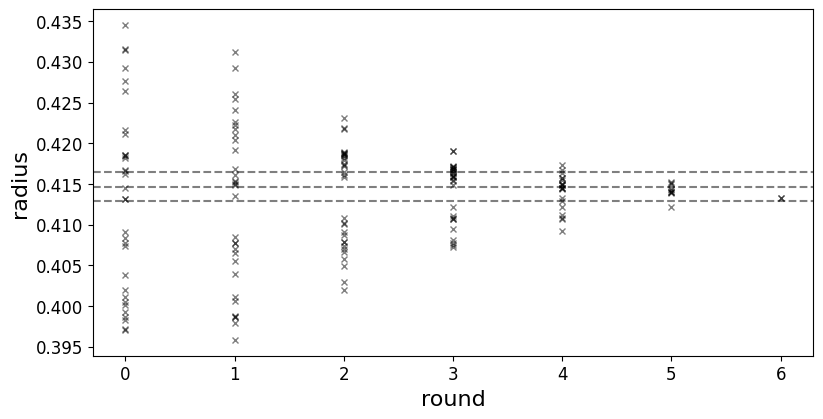

(0.415, 0.002)


In [15]:
# Examine running estimated effective radius convergence over all MC realizations

plt.figure(figsize=(8, 4))

for rs in result.rads:
    plt.errorbar(range(len(rs)), rs, color='black', fmt='x', ms=4, alpha=0.5)

rs = np.asarray([r for *_, r in result.rads])
r_center = np.mean(rs)
r_spread = np.std(rs)

plt.axhline(r_center - r_spread, linestyle='dashed', color='black', alpha=0.5)
plt.axhline(r_center, linestyle='dashed', color='black', alpha=0.5)
plt.axhline(r_center + r_spread, linestyle='dashed', color='black', alpha=0.5)

plt.tight_layout()
plt.xlabel(r"round", fontsize=16)
plt.ylabel(r"radius", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

print(f'({r_center:.3f}, {r_spread:.3f})')

In [16]:
# Extract radius data from domain

n, m = 64, 64
rads = []
rads_all = []
ds, factors = rays(dimension, n, m)
for cell in result.cells:
    pass
    keys, rh, _ = cell.boundary(n, m, center, ds)
    rg = np.mean(rh[keys != -1]**dimension)**(1/dimension)
    rads.append(rg)
    rads_all.append(rh)
rads_all = np.array(rads_all)
rads_all = np.hstack(rads_all)

rs = np.asarray(rads)
r_center = np.mean(rs)
r_spread = np.std(rs)

print(f'({r_center:.3f}, {r_spread:.3f})')

(0.415, 0.002)


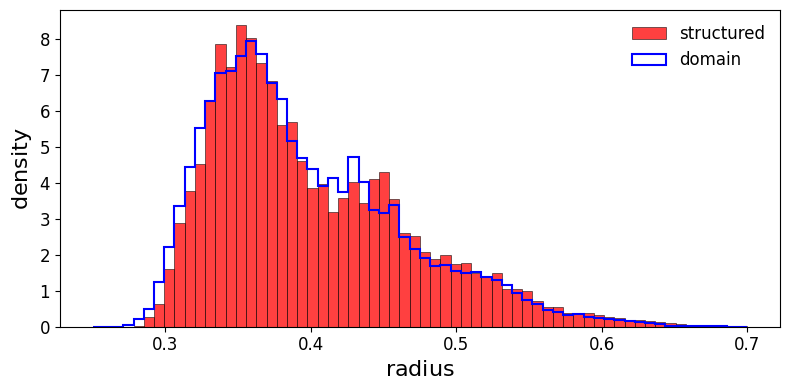

In [17]:
# Compare the distributions of final stable radii obtained using a fine structured grid and domain construction
# Since the radii in the domain represent unstable initial conditions, the structured grid results are shifted

plt.figure(figsize=(8, 4))

plt.hist(rb_refine - dr/2, 64, range=(0.25, 0.7), density=True, color='red', alpha=0.75, edgecolor='black', linewidth=0.5, label=r"structured")
plt.hist(rads_all, 64 , range=(0.25, 0.7), density=True, histtype='step', linewidth=1.5, color='blue', label=r"domain")

plt.xlabel(r"$\mathrm{radius}$", fontsize=16)
plt.ylabel(r"$\mathrm{density}$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

In [18]:
# Process convergence data

table = []
for data in zip(result.data):
    data, *_ = data
    missed, hit, total = zip(*data)
    total, *_ = total
    missed = 100*np.array(missed)/total
    hit = 100*np.array(hit)/total
    table.append([missed, hit])
missed, hit = zip(*table)

In [19]:
# Number of rounds to reach 95% coverage

np.median(np.asarray([*map(len, missed)]))

np.float64(5.0)

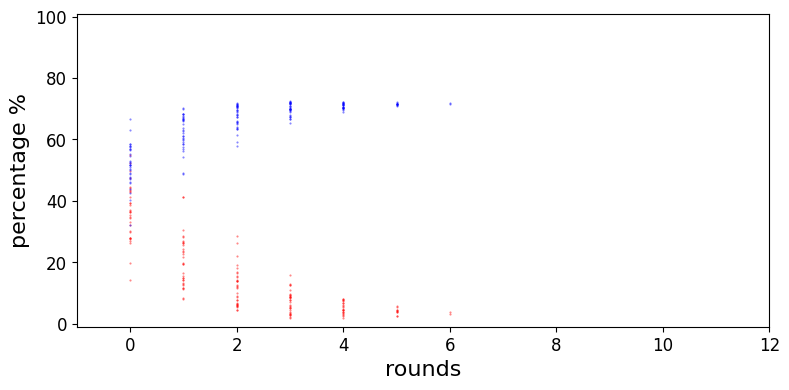

In [20]:
# Convergence

plt.figure(figsize=(8, 4))

for x in missed:
    plt.errorbar(range(len(x)), x, color='red', fmt='.', ms=1, alpha=0.5)

plt.tight_layout()
plt.xlabel(r"rounds", fontsize=16)
plt.ylabel(r"missed %", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1, 101)
plt.ylim(-1, 101)

for x in hit:
    plt.errorbar(range(len(x)), x, color='blue', fmt='.', ms=1, alpha=0.5)

plt.xlabel(r"rounds", fontsize=16)
plt.ylabel(r"percentage %", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1, 12)
plt.ylim(-1, 101)
plt.tight_layout()
plt.show()

In [21]:
# Compare cost (average expected evaluation cost without MC)
# With MC this cost should be multiplied by number of MC rounds

data = np.array([cs + cs + np.sum(array) for cs, cs, array in result.costs])

print(f'{np.log10(ct):>6.2f}')
print(f'{np.log10(np.mean(data)):>6.2f}')

 10.94
  8.93


In [22]:
# Grow the domain (uniform)

domain = Domain(lb, ub, dl)
domain.insert(result.container.keys)

orbits = np.empty((nsamples*npoints, size, dimension), dtype=np.float64)

for epoch in range(128):
    indices = np.random.choice(domain.list, nsamples)
    centers = domain.transform(indices)
    initial = sample(npoints, scale*dl, centers)
    scan(initial, orbits, orbit(size, threshold, mapping), knobs)
    points = orbits[mask(orbits, threshold)].reshape(-1, dimension)
    points = filter(points, threshold)
    domain.update(points)
    print(f'{epoch + 1:02d}', f'{domain.size:12d}')
    if domain.size > 100_000_000:
        break

01     18323700
02     18416407
03     18505880
04     18597949
05     18686243
06     18778043
07     18867034
08     18953847
09     19038796
10     19123861
11     19212407
12     19298418
13     19386221
14     19466368
15     19544138
16     19625354
17     19707127
18     19789917
19     19870916
20     19950516
21     20028373
22     20103953
23     20182749
24     20256509
25     20329995
26     20405293
27     20483886
28     20559740
29     20635135
30     20709195
31     20782959
32     20857628
33     20930622
34     21002630
35     21073715
36     21144031
37     21211440
38     21282557
39     21353114
40     21422137
41     21491049
42     21560139
43     21630531
44     21700274
45     21768997
46     21835447
47     21903018
48     21971249
49     22040346
50     22110835
51     22177896
52     22243367
53     22310027
54     22373679
55     22437706
56     22503093
57     22564806
58     22628078
59     22691873
60     22756080
61     22820303
62     22880566
63     2

In [23]:
# Extract cell center points and define mask for each plane

epsilon = 1.0E-6
width = 0

Qx, Qy, Px, Py = domain.construct.T

mqx = np.abs(Qx) < width*dl + epsilon
mqy = np.abs(Qy) < width*dl + epsilon
mpx = np.abs(Px) < width*dl + epsilon
mpy = np.abs(Py) < width*dl + epsilon

In [24]:
# qx-qy

In [25]:
n = 1000
qx = np.linspace(-1.5, 1.5, n)
qy = np.linspace(-1.5, 1.5, n)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

mask_qxqy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy, complexity, knobs)

ds = directions(dimension, 256, random=False, ij=(0, 1), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxa, qya, pxa, pya = xs.T

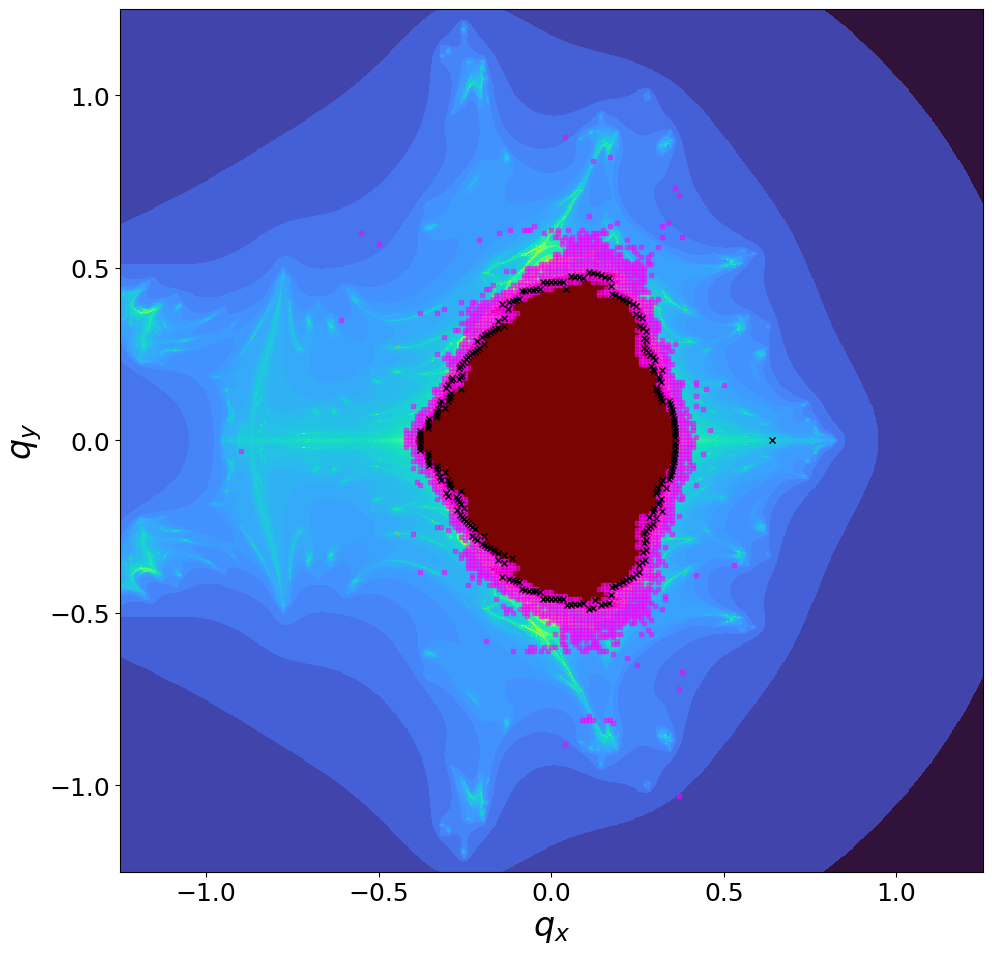

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + mask_qxqy).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5))
pa, *_ = ax.transData.transform((0.00, 0.00))
pb, *_ = ax.transData.transform((dl, 0.00))
ms = ((pa - pb)*72.0/fig.dpi)**2
ax.errorbar(Qx[mpx*mpy], Qy[mpx*mpy], color='magenta', fmt=' ', ms=ms, marker='s', alpha=0.5)
ax.errorbar(qxa, qya, color='black', fmt=' ', marker='x', ms=4)
plt.xlabel('qx')
plt.ylabel('qy')
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_x$", fontsize=24)
plt.ylabel(r"$q_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [27]:
# qx-px

In [28]:
n = 1000
qx = np.linspace(-1.5, 1.5, n)
px = np.linspace(-1.5, 1.5, n)
qxpx = np.stack(np.meshgrid(qx, px, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qypy = np.full_like(qxpx, 0.0)
qx, px = qxpx.T
qy, py = qypy.T
xs = np.stack([qx, qy, px, py]).T

mask_qxpx = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxpx, complexity, knobs)

ds = directions(dimension, 256, random=False, ij=(0, 2), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxb, qyb, pxb, pyb = xs.T

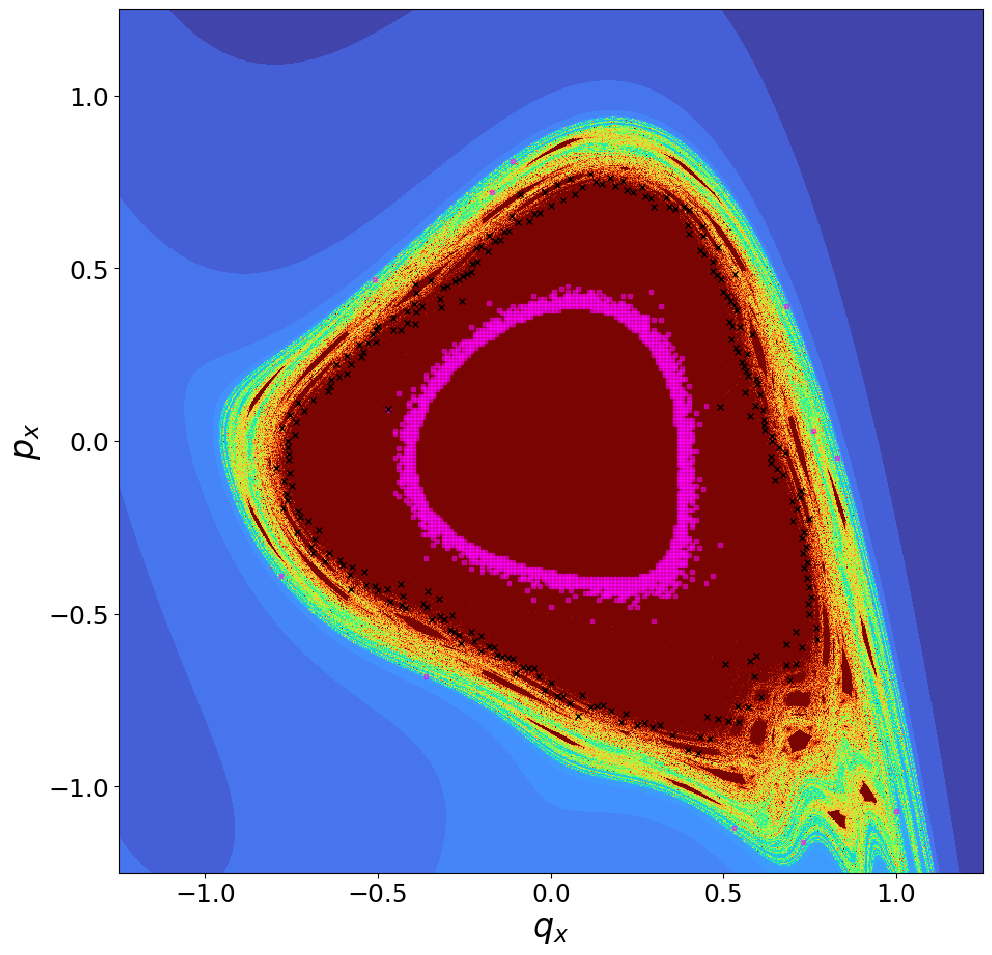

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + mask_qxpx).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5))
pa, *_ = ax.transData.transform((0.00, 0.00))
pb, *_ = ax.transData.transform((dl, 0.00))
ms = ((pa - pb)*72.0/fig.dpi)**2
ax.errorbar(Qx[mqy*mpy], Px[mqy*mpy], color='magenta', fmt=' ', ms=ms, marker='s', alpha=0.5)
ax.errorbar(qxb, pxb, color='black', fmt=' ', marker='x', ms=4)
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_x$", fontsize=24)
plt.ylabel(r"$p_x$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [30]:
# qy-py

In [31]:
n = 1000
qy = np.linspace(-1.5, 1.5, n)
py = np.linspace(-1.5, 1.5, n)
qypy = np.stack(np.meshgrid(qy, py, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qxpx = np.full_like(qypy, 0.0)
qy, py = qypy.T
qx, px = qxpx.T
xs = np.stack([qx, qy, px, py]).T

mask_qypy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qypy, complexity, knobs)

ds = directions(dimension, 256, random=False, ij=(1, 3), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxc, qyc, pxc, pyc = xs.T

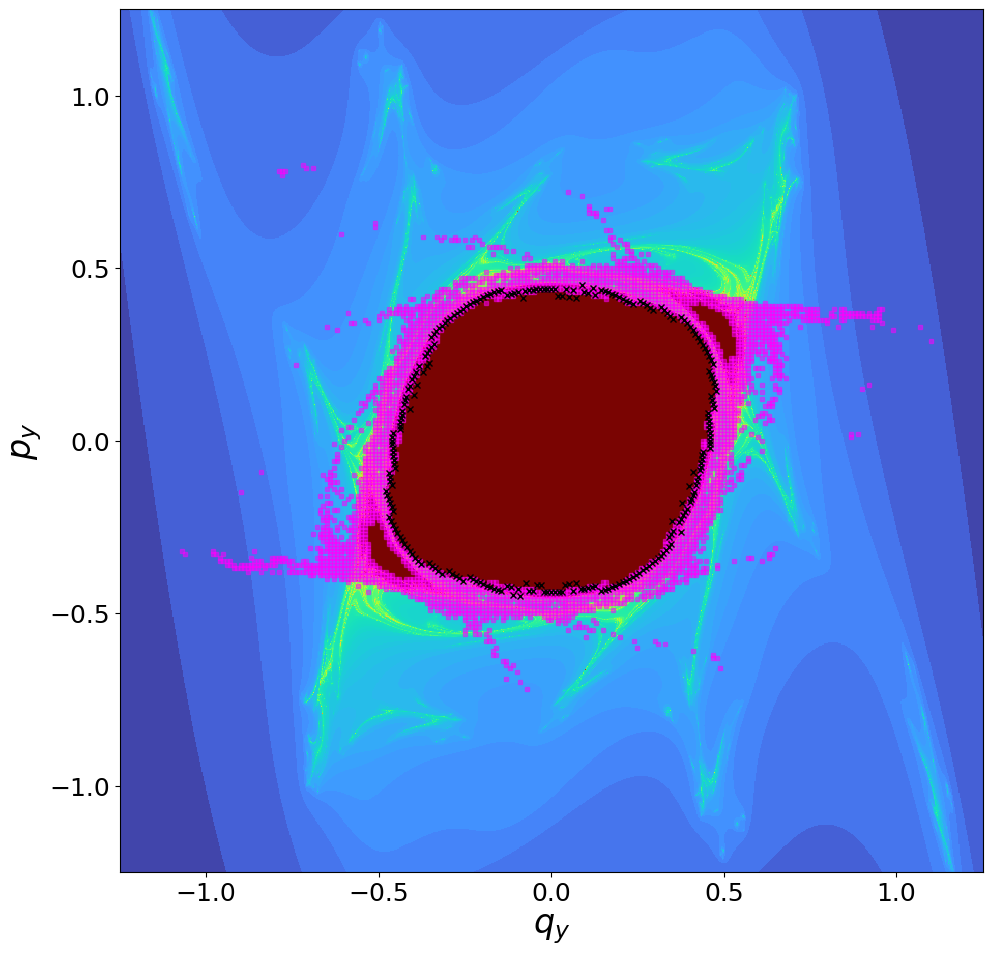

In [32]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + mask_qypy).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5))
pa, *_ = ax.transData.transform((0.00, 0.00))
pb, *_ = ax.transData.transform((dl, 0.00))
ms = ((pa - pb)*72.0/fig.dpi)**2
ax.errorbar(Qy[mqx*mpx], Py[mqx*mpx], color='magenta', fmt=' ', ms=ms, marker='s', alpha=0.5)
ax.errorbar(qyc, pyc, color='black', fmt=' ', marker='x', ms=4)
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_y$", fontsize=24)
plt.ylabel(r"$p_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [33]:
# px-py

In [34]:
n = 1000
px = np.linspace(-1.5, 1.5, n)
py = np.linspace(-1.5, 1.5, n)
pxpy = np.stack(np.meshgrid(px, py, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qxqy = np.full_like(pxpy, 0.0)
px, py = pxpy.T
qx, qy = qxqy.T
xs = np.stack([qx, qy, px, py]).T

mask_pxpy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_pxpy, complexity, knobs)

ds = directions(dimension, 256, random=False, ij=(2, 3), omega_min=0.0, omega_max=2*np.pi)
rs, xs = da(dimension, dr, threshold, center, ds, objective, knobs)
qxd, qyd, pxd, pyd = xs.T

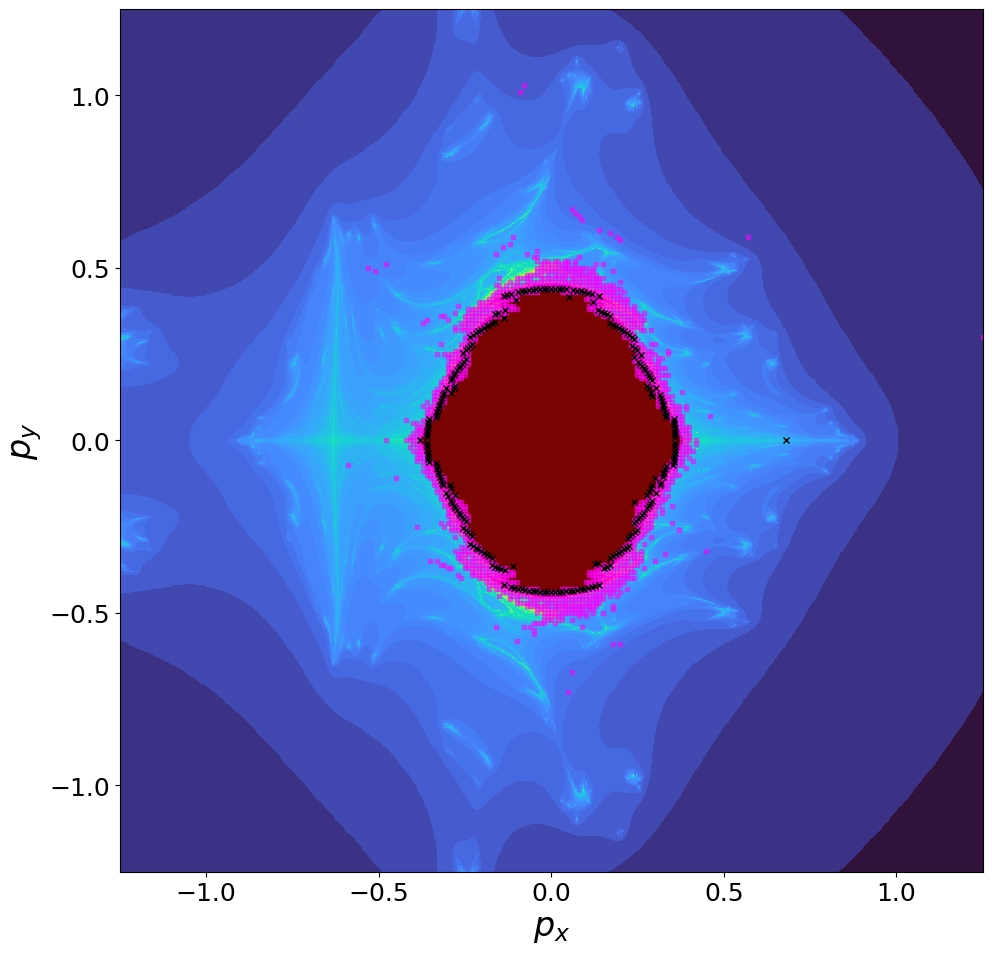

In [35]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + mask_pxpy).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5))
pa, *_ = ax.transData.transform((0.00, 0.00))
pb, *_ = ax.transData.transform((dl, 0.00))
ms = ((pa - pb)*72.0/fig.dpi)**2
ax.errorbar(Px[mqx*mqy], Py[mqx*mqy], color='magenta', fmt=' ', ms=ms, marker='s', alpha=0.5)
ax.errorbar(pxd, pyd, color='black', fmt=' ', marker='x', ms=4)
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$p_x$", fontsize=24)
plt.ylabel(r"$p_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()